Sheet 2.1: Character-level language modelling
===
**Author**: Amir Mohammadpour

We now know what a language model is: a probability distribution assigned to a set of sequences. But how can we build one using a simple multi-layer perceptron?

The core difficulty is that sequences have variable length, and MLPs do not. A network with fixed input dimensions cannot, in any straightforward sense, take a sequence as input. The standard resolution — due to Bengio et al. (2003) — is to abandon the full sequence and instead condition on a fixed-size context window of the last $n$ characters. The model sees exactly $n$ characters at every prediction step, no more. It learns to embed each character as a dense vector, concatenates those vectors into a fixed-size input, and passes the result through a feedforward network to produce a probability distribution over the next character.

In the first part of this tutorial, we train an MLP-based LM, and evaluate its performance with simple measures. Then in the second part, we try to replicate our MLP-based LM with a recurrent neural network, that is inherently sequential.

This tutorial builds on [Andrej Karpathy's makemore](https://github.com/karpathy/nn-zero-to-hero/tree/master/lectures/makemore).

First, the usual stuff — import whatever we need throughout this notebook

In [107]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random
%matplotlib inline

import time

---
## 1 . The Data

The dataset is a list of 32,033 human names. The modeling task is next-character prediction: given some context, assign a probability to each possible next character. For that, we need a vocabulary. Every unique character in the dataset gets an integer index; a special token `.` serves as both the start and end of every name. The cell below loads the data and builds those mappings.

In [94]:
# Read in all the words
words = open('names.txt', 'r').read().splitlines()
print(f"Total words: {len(words)}")
print("First 8 words:", words[:8])

# Build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print("Vocabulary:", itos)
vocab_size = len(itos)
print(f"Vocabulary size: {vocab_size}")

Total words: 32033
First 8 words: ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']
Vocabulary: {1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
Vocabulary size: 27


With the vocabulary established, we can construct the training data. Each name is processed character by character: at every step, the model receives the last `block_size` characters as context and must predict the next one. Positions before the first character of a name are padded with the `.` token. The dataset is split 80/10/10 into training, validation, and test sets — the validation set is what you will use to measure the effect of any intervention you make during the session.

> **Think about it.** Print the first few rows of `Xtr` and decode them back to characters. What do the contexts for the first two or three characters of a name look like? What does the model have to predict the second character of a name from?

In [95]:
# Build the dataset
block_size = 5 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(f"X shape: {X.shape}, Y shape: {Y.shape}")
  return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

X shape: torch.Size([182625, 5]), Y shape: torch.Size([182625])
X shape: torch.Size([22655, 5]), Y shape: torch.Size([22655])
X shape: torch.Size([22866, 5]), Y shape: torch.Size([22866])


---
## 2 . From Characters to vectors

Before we can pass characters through a neural network, we need to represent them as numbers. The obvious choice — the integer indices we just built — would impose an arbitrary ordering on the vocabulary: the network might infer that character 3 is somehow "between" characters 2 and 4, which is meaningless. Instead, we learn a dedicated vector for each character, stored in an embedding table: a matrix of shape `(vocab_size, embedding_dim)` where row $i$ is the learned representation of character $i$. Looking up the embedding of a character is then just an integer index into this matrix — cheap, differentiable, and learned end-to-end alongside everything else.

Given a context window of `block_size` characters, we retrieve the corresponding embedding vectors and concatenate them into a single flat vector. That vector is the input to our neural network.

### A look-up table

Before delegating to PyTorch, it is worth seeing what an embedding table actually is at the tensor level. We initialize a random matrix C of shape (vocab_size, n_embd) and index into it directly — retrieving one row per character, one set of rows per context window. As you can see, this is merely a look-up table for our characters.

In [96]:
n_embed = 2
C = torch.randn((vocab_size, n_embed))
emb = C[Xtr[:5]]  # retrieve embeddings for the first 5 training examples
print(f"Context indices shape: {Xtr[:5].shape}")       # (5, block_size)
print(f"Embedding output shape: {emb.shape}")          # (5, block_size, n_embd)
print(f"Flat input to MLP: {emb.view(5, -1).shape}")   # (5, block_size * n_embd)

Context indices shape: torch.Size([5, 5])
Embedding output shape: torch.Size([5, 5, 2])
Flat input to MLP: torch.Size([5, 10])


---
## 3 . The Model

The full architecture follows directly from the setup above. Four components, each with a clear job.

The **embedding table** (`nn.Embedding`) maps each character index to a dense vector of dimension `n_embd`. For a context window of `block_size` characters, we retrieve `block_size` such vectors and flatten them into a single input of dimension `block_size × n_embd`. This is the fixed-size representation that makes the MLP tractable — the variable-length sequence has been reduced to a fixed-length vector by the decision to condition on exactly the last `block_size` characters, and nothing else.

The **first linear layer** (`fc1`) projects that concatenated input down to a hidden representation of size `n_hidden`, followed by a tanh nonlinearity. This is where the model has the opportunity to learn interactions between characters at different positions in the context window — whether the combination of an "a" two steps ago and an "n" one step ago makes an "n" now more or less likely, for instance.

The **output layer** (`fc2`) is a linear projection from the hidden representation to `vocab_size` logits — one per character in the vocabulary. These logits are passed to a softmax to produce a probability distribution over the next character, though during training we will hand them directly to the cross-entropy loss, which handles the softmax internally.

Two hyperparameters control the model's capacity: `n_embd`, the dimensionality of the character embeddings, and `n_hidden`, the width of the hidden layer. Both are fair targets for experimentation during the session.

In [112]:
# MLP Model Definition using fixed context window
n_embd = 2 # the dimensionality of the character embedding vectors
n_hidden = 50 # the number of neurons in the hidden layer of the MLP

class CharMLP(nn.Module):
    def __init__(self, vocab_size, n_embd, n_hidden, block_size):
        super().__init__()
        # Embedding logic
        self.C = nn.Embedding(vocab_size, n_embd)
        
        # We concatenate the embeddings of the complete block (context), flatting them out
        self.fc1 = nn.Linear(n_embd * block_size, n_hidden)
        self.tanh = nn.Tanh()
        self.fc2 = nn.Linear(n_hidden, vocab_size)
    
    def forward(self, idx):
        # idx is a tensor of indices (B, block_size)
        emb = self.C(idx) # (B, block_size, n_embd)
        
        # Flatten the embeddings
        emb = emb.view(emb.shape[0], -1) # (B, block_size * n_embd)
        
        # Hidden layer
        h = self.tanh(self.fc1(emb)) # (B, n_hidden)
        
        # Output layer
        logits = self.fc2(h) # (B, vocab_size)
        return logits

# Set seed BEFORE model initialization so weight initialization is fully reproducible
torch.manual_seed(42)

model = CharMLP(vocab_size, n_embd, n_hidden, block_size)
print(model)
print(sum(p.numel() for p in model.parameters()), "parameters")

CharMLP(
  (C): Embedding(27, 2)
  (fc1): Linear(in_features=10, out_features=50, bias=True)
  (tanh): Tanh()
  (fc2): Linear(in_features=50, out_features=27, bias=True)
)
1981 parameters


---
## 4 . Training

Training follows the same four-step loop established in Tutorial 2: sample a minibatch, run the forward pass, compute the loss, backpropagate and update. The loss function is cross-entropy — it combines the softmax over logits and the negative log-likelihood into a single numerically stable operation, so the model's raw logits can be passed directly without an explicit softmax beforehand.

A few things are worth attending to here. The batch size is small (8), which means each update is noisy — the gradient computed on 8 examples is a rough approximation of the true gradient over the full dataset. This introduces variance into training but also acts as a form of regularization and keeps each step cheap.

> **Think about it.** What do you expect to happen to the loss curve if you increase the batch size to 256? Will it be smoother, noisier, higher, lower — and why?

The learning rate is set to `0.01` throughout. You will notice a commented-out block that reduces it sharply after a large number of steps. The intuition behind that pattern is straightforward: early in training, large steps help the model move quickly through the loss landscape; later, when the model is closer to a good solution, the same step size may cause it to overshoot. Reducing the learning rate at that point allows finer adjustments. Uncomment that block and observe whether it changes the final loss.

      0/  10000: 2.4875
   1000/  10000: 2.3809
   2000/  10000: 2.8638
   3000/  10000: 2.1839
   4000/  10000: 2.2443
   5000/  10000: 2.2875
   6000/  10000: 2.0601
   7000/  10000: 2.2176
   8000/  10000: 2.1932
   9000/  10000: 1.9177
Training time: 3.98 seconds


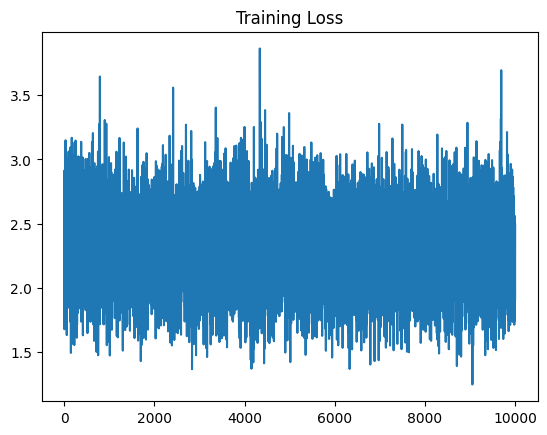

In [121]:
# Training the MLP
max_steps = 10000
batch_size = 16
lossi = []

# Move to training loop
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

time1 = time.time()

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb) # Cross Entropy combines Softmax + Log-Likelihood
  
  # backward pass
  optimizer.zero_grad()
  loss.backward()
  
  # # update
  # lr = 0.001 if i < 1000 else 0.0001 # step learning rate decay
  # for param in optimizer.param_groups:
  #     param['lr'] = lr
      
  optimizer.step()
  
  # track stats
  if i % 1000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.item())

time2 = time.time()
print(f"Training time: {time2 - time1:.2f} seconds")

plt.plot(lossi);
plt.title('Training Loss');

## 5 . Evaluation

Training loss is a poor guide to model quality — it is computed on minibatches during optimization and reflects the model's performance on data it has already seen. What matters is how well the model generalizes to new names. The function below runs a full forward pass on each split and reports the cross-entropy loss, with gradients disabled since we are not updating anything.

Run it now and note the gap between training and validation loss. A large gap is a sign of overfitting — the model has memorized patterns specific to the training set that do not generalize. A small gap where both losses are high suggests the model is underfitting — it has not learned enough from the data it has seen. Both are useful diagnostics before you start intervening.

In [114]:
# Evaluation on Train/Dev/Test sets
@torch.no_grad()
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  
  # Forward pass
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.704556703567505
val 2.698561906814575


### Generating new names

Loss is an aggregate measure — it tells you how wrong the model is on average, but not what kind of names it thinks are plausible. Sampling from the model directly is a more intuitive diagnostic. Starting from a context of `block_size` padding tokens, we repeatedly ask the model for a probability distribution over the next character, sample from it, shift the context window forward, and continue until the stop token is drawn.

A few things to notice. The sampling is stochastic — `torch.multinomial` draws from the distribution rather than taking the argmax, so the same model produces different names on different runs. The generator is seeded for reproducibility, but changing the seed will give you a different set of names without changing the model at all. The quality of the output is a qualitative complement to the quantitative loss: a model with a low validation loss should produce names that are, on the whole, more plausible-sounding than one that is still underfitting.

In [115]:
# Generative Sampling
# Sample from the model following makemore's generative process
g = torch.Generator().manual_seed(42)

for _ in range(10): # generate 10 names
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        # forward pass
        context_tensor = torch.tensor([context])
        logits = model(context_tensor)
        probs = F.softmax(logits, dim=1)
        
        # sample next token from the distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        
        # adjust context window and record token
        context = context[1:] + [ix] # shift context window
        if ix == 0:
            break # break on stop token '.'
        out.append(ix)
    
    # decode the generated sequence to a string
    print(''.join(itos[i] for i in out))

anugeenvt
a
aabiqu
dxemubn
msilaylga
oemah
laoln
eaiac
odanldkzm
anacn


---
## A Recurrent Alternative

The MLP's context window is a design decision made before training begins: the model receives exactly `block_size` characters at every step, and whatever occurred before that window is architecturally inaccessible. A recurrent neural network replaces that fixed window with a hidden state — a fixed-size vector that is updated at each step as a function of the current input and the previous hidden state. What the hidden state retains, and how it is updated, is learned from data rather than fixed by the architecture.

A recurrent neural network replaces that fixed window with a hidden state vector — a learned, fixed-size summary of everything the network has processed so far. Rather than concatenating a fixed context into a flat input, an RNN processes the sequence one character at a time, updating the hidden state at each step. The crucial difference is that the hidden state is computed by the network itself: what gets retained, what gets discarded, and how the current character modifies the summary are all learned from data. The MLP's context window, by contrast, is a design decision made before training begins.

Whether that additional flexibility translates into better performance depends on the data. On a small dataset of short names, the MLP's fixed window may already capture most of the structure that matters — names are short enough that long enough `block_size` covers a significant fraction of any name's full length. The RNN's advantage tends to emerge on longer sequences, where long-range dependencies matter more. Therefore, we might not see a dramatic improvement here.

### The Recurrence, Explicitly

Before delegating to `nn.RNN`, it is worth implementing the recurrence by hand. The update equation at each timestep $t$ is:

$$h_t = \tanh(W_{xh}\, x_t + W_{hh}\, h_{t-1} + b)$$

where $x_t$ is the current input embedding and $h_{t-1}$ is the hidden state carried forward from the previous step. `myRNN` implements this loop explicitly using a single `nn.Linear` layer that takes the concatenation of $x_t$ and $h_{t-1}$ as input — the two matrix multiplications in the equation above merged into one.

The backward pass through this architecture — backpropagation through time (BPTT) — follows the same chain rule logic as any other network, except the computation graph now extends across timesteps. Gradients flow backward through every application of the recurrence, all the way to $h_0$. For long sequences this means gradients must survive many successive multiplications by the same weight matrix, which is what makes training vanilla RNNs on long-range dependencies unreliable. Gradient clipping, applied in the training loop below, is a standard palliative.

In [116]:
class myRNN(nn.Module):
    def __init__(self, vocab_size, n_embd, n_hidden):
        super().__init__()
        self.n_hidden = n_hidden
        self.i2h = nn.Linear(n_embd + n_hidden, n_hidden)
    
    def forward(self, emb):
        # emb is (B, block_size, n_embd) — already embedded, no index lookup here
        B, T, _ = emb.shape
        h = torch.zeros(B, self.n_hidden, device=emb.device)
        out = []
        for t in range(T):
            x_t = emb[:, t, :]
            h = torch.tanh(self.i2h(torch.cat([x_t, h], dim=1)))
            out.append(h.unsqueeze(1))
        out = torch.cat(out, dim=1) # (B, block_size, n_hidden)
        # Note: PyTorch's nn.RNN returns h_n as (num_layers, B, n_hidden),
        # so we unsqueeze to match the expected format: (1, B, n_hidden)
        return out, h.unsqueeze(0)


> **Think about it.** `CharRNN` is currently using `nn.RNN`. You have `myRNN` available. Should swapping one for the other — keeping everything else fixed — produce exactly the same loss trajectory? If not, what would differ and why? Try the swap and see if your prediction holds.

In [118]:
# RNN Model Definition
n_embd = 2
n_hidden = 50

class CharRNN(nn.Module):
    def __init__(self, vocab_size, n_embd, n_hidden):
        super().__init__()
        self.C = nn.Embedding(vocab_size, n_embd)
        
        # RNN layer
        # batch_first=True makes input shape (batch, seq, feature)
        self.rnn = nn.RNN(n_embd, n_hidden, batch_first=True)
        # self.rnn = myRNN(vocab_size, n_embd, n_hidden)

        # Output layer maps hidden state to vocabulary distribution
        self.fc = nn.Linear(n_hidden, vocab_size)
    
    def forward(self, idx):
        # idx is (B, block_size)
        emb = self.C(idx) # (B, block_size, n_embd)
        
        # RNN over the sequence
        out, h_n = self.rnn(emb) # out is (B, block_size, n_hidden)
        
        # We only care about the output from the final time step to predict the next word
        last_hidden = out[:, -1, :] # (B, n_hidden)
        
        logits = self.fc(last_hidden) # (B, vocab_size)
        return logits

# Set manual seed for reproducibility of weight initialization
torch.manual_seed(42)

model = CharRNN(vocab_size, n_embd, n_hidden)
print(model)
print(sum(p.numel() for p in model.parameters()), "parameters")

CharRNN(
  (C): Embedding(27, 2)
  (rnn): RNN(2, 50, batch_first=True)
  (fc): Linear(in_features=50, out_features=27, bias=True)
)
4131 parameters


      0/  10000: 2.1819
   1000/  10000: 2.3062
   2000/  10000: 2.1494
   3000/  10000: 2.8184
   4000/  10000: 2.0629
   5000/  10000: 2.4726
   6000/  10000: 2.6249
   7000/  10000: 2.9323
   8000/  10000: 2.2777
   9000/  10000: 1.7942
Training time: 3.93 seconds


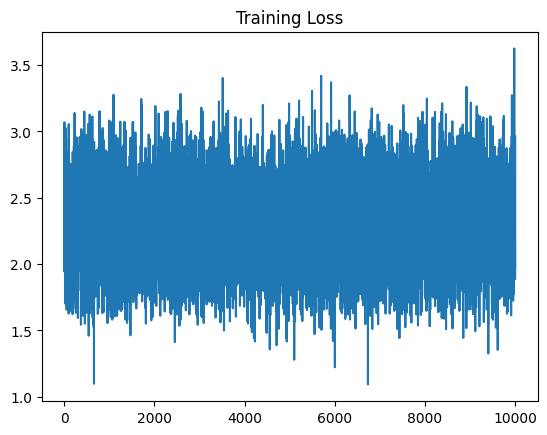

In [122]:
# Training the RNN
max_steps = 10000
batch_size = 16
lossi = []

optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

time1 = time.time()
for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
  
  # forward pass
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb)
  
  # backward pass
  optimizer.zero_grad()
  loss.backward()
  
  # update with step learning rate decay
  lr = 0.1 if i < 30000 else 0.01 
  for param in optimizer.param_groups:
      param['lr'] = lr
      
  optimizer.step()
  
  # track stats
  if i % 1000 == 0: 
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.item())
time2 = time.time()
print(f"Training time: {time2 - time1:.2f} seconds")
plt.plot(lossi);
plt.title('Training Loss');

In [ ]:
# Evaluation on Train/Dev/Test sets
@torch.no_grad()
def split_loss(split):
  x, y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  
  # Forward pass
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.9823139905929565
val 2.0522007942199707


In [ ]:
# Generative Sampling
g = torch.Generator().manual_seed(42)

for _ in range(10): # generate 10 names
    out = []
    context = [0] * block_size # initialize context window
    while True:
        # forward pass
        context_tensor = torch.tensor([context])
        logits = model(context_tensor)
        probs = F.softmax(logits, dim=1)
        
        # sample next token
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        
        # shift context window and append new token
        context = context[1:] + [ix] 
        if ix == 0:
            break 
        out.append(ix)
    
    # print string
    print(''.join(itos[i] for i in out))

anuston
kis
marian
dante
naysia
yanie
joshlen
lenni
caslee
jamie
